In [1]:
import eos
import os
import numpy as np
import matplotlib.pyplot as plt
import ast
import cmath

colors = eos.figure.ItemColorCycler()._colors

resample = False

In [2]:
BASE_DIRECTORY = os.getcwd()
if not os.path.exists(BASE_DIRECTORY):
    os.makedirs(os.path.abspath(BASE_DIRECTORY), exist_ok=True)

In [3]:
def wstd(samples, weights=None, axis=0):
    mean_w = np.average(samples, weights=weights, axis=axis)
    return np.sqrt(np.average((samples - mean_w)**2, weights=weights, axis=axis))

def get_gof(analysis, param_array):
    parameter_list = []

    for param in analysis.init_args['priors']:
        if param['type'] == 'transform':
            parameter_list += param['parameters']
        else:
            parameter_list.append(param['parameter'])

    for i, param in enumerate(parameter_list):
        analysis.parameters.set(param, param_array[i])

    return analysis.goodness_of_fit()

In [4]:
def a11_calculator(sl_params):
    # f''/f at psi+ * coefficent + f'''/f at psi+ * coefficent
    return sl_params[0] * (-0.365625798636340) + sl_params[1] * 0.065122863429160

def charge_radius_squared_calculator(fprime_values):
    # 6 * df/dpsi at psi(0) * dpsi/ds at s=0 * (hbar c)^2
    return 6 * fprime_values * (-1.31241754914090000000) * (0.19732697178003900000)**2 #fm^2

In [5]:
def get_f_rho(sample, ana):
    get_gof(ana, sample)
    s_rho = (sample[0] - 1j * sample[1] / 2)**2
    return [eos.Observable.make("0->pipi::Re{f_+}(Re{q2},Im{q2})",
                        ana.parameters,
                        eos.Kinematics({"Re{q2}": np.real(s_rho), "Im{q2}": np.imag(s_rho)}),
                        eos.Options({'form-factors': "BHKMNR2026", "n-resonances": '1'})).evaluate(),
            eos.Observable.make("0->pipi::Im{f_+}(Re{q2},Im{q2})",
                        ana.parameters,
                        eos.Kinematics({"Re{q2}": np.real(s_rho), "Im{q2}": np.imag(s_rho)}),
                        eos.Options({'form-factors': "BHKMNR2026", "n-resonances": '1'})).evaluate()]

def get_f_bfp(ana, bfp, q2):
    get_gof(ana, bfp)
    return eos.Observable.make("0->pipi::Abs{f_+}^2(q2)",
                        ana.parameters,
                        eos.Kinematics({'q2': q2}),
                        eos.Options({'form-factors': "BHKMNR2026", "n-resonances": '1'})).evaluate()

def get_f_arg_bfp(ana, bfp, q2):
    get_gof(ana, bfp)
    return eos.Observable.make("0->pipi::Arg{f_+}(q2)",
                        ana.parameters,
                        eos.Kinematics({'q2': q2}),
                        eos.Options({'form-factors': "BHKMNR2026", "n-resonances": '1'})).evaluate()

def get_f_arg_of_psi_bfp(ana, bfp, psi):
    get_gof(ana, bfp)
    return eos.Observable.make("0->pipi::Arg{f_+}(Re{psi},Im{psi})@BHKMNR2026",
                        ana.parameters,
                        eos.Kinematics({'Re{psi}': np.real(psi), 'Im{psi}': np.imag(psi)}),
                        eos.Options({'form-factors': "BHKMNR2026", "n-resonances": '1'})).evaluate()

def get_f_abs_of_psi_bfp(ana, bfp, psi):
    get_gof(ana, bfp)
    return eos.Observable.make("0->pipi::Abs{f_+}^2(Re{psi},Im{psi})@BHKMNR2026",
                        ana.parameters,
                        eos.Kinematics({'Re{psi}': np.real(psi), 'Im{psi}': np.imag(psi)}),
                        eos.Options({'form-factors': "BHKMNR2026", "n-resonances": '1'})).evaluate()

In [6]:
mpi    = eos.Parameters()["mass::pi^+"].evaluate()
sPlus  = 4 * mpi**2
sMinus = 0.0
sIn    = 0.85051 #pi-omega threshold

In [7]:
def phi_11(s: complex) -> complex:
        return (cmath.sqrt(sIn - s) - cmath.sqrt(sIn - sPlus)) / cmath.sqrt(sPlus - s)

def phi_21(s: complex) -> complex:
        return -phi_11(s)

phi_L = phi_21(sMinus)
phi_0 = phi_11(sMinus)

In [8]:
def chi(x: complex) -> complex:

    A = (x * (phi_L -1)**2 - phi_L * (x - 1)**2) * (phi_0 - 1)**2
    B = (phi_0 * (phi_L -1)**2 - phi_L * (phi_0- 1)**2) * (x - 1)**2

    sqrtA = cmath.sqrt(A)
    sqrtB = cmath.sqrt(B)

    return (sqrtA - sqrtB) / (sqrtA + sqrtB)


def phi_to_psi(phi: complex) -> complex:

    if abs(phi) <= 1:
        return chi(phi)
    else:
        return 1.0 / chi(1.0 / phi)


def chi_inv(y: complex) -> complex:

    A = (y - 1)**2 * (phi_L - 1)**2 * (phi_0 - 1)**2
    B = 4 * phi_0 * (y + 1)**2 * (phi_L - 1)**2 - 16 * y * phi_L * (phi_0 - 1)**2

    sqrtA  = cmath.sqrt(A)
    sqrtAB = cmath.sqrt(A + B)

    return (sqrtAB - sqrtA) / (sqrtAB + sqrtA)


def psi_to_phi(psi: complex) -> complex:

    if abs(psi) <= 1:
        return chi_inv(psi)
    else:
        return 1.0 / chi_inv(1.0 / psi)


def phi_to_s(phi: complex) -> complex:
        return (sPlus * (1 + phi**2)**2 - 4 * sIn * phi**2) / ((1 - phi**2)**2)


In [9]:
def is_on_11_sheet(psi: complex) -> bool:

    phi = psi_to_phi(psi)
    return abs(phi) < 1.0 and phi.real > 0

def has_no_roots_on_11_sheet(a: list[float]) -> bool:

    roots = np.polynomial.polynomial.polyroots(a)
    return not any(is_on_11_sheet(r) for r in roots)

In [10]:
af = eos.AnalysisFile(os.path.join(os.getcwd(), 'analysis.yaml'))

## N = 9, 3 resonances


In [36]:
posterior = 'FF-fp-I1-order9-3resonances'
analysis  = af.analysis(posterior)

Creating analysis with 12 priors, 3 EOS-wide constraints, 2 global options, 2 manually-entered constraints and 2 fixed parameters.
likelihood probably depends on 5 parameter(s) that do not appear in the prior; check prior?


In [43]:
start_point = [0.76190866,  0.1449684 ,  1.01460076,  0.38544644,  1.5624366 ,
        0.38681348,  0.80132518, -0.33622777, -0.22255347,  0.10888967,
        0.08857415, -0.23712675]

In [44]:
get_gof(analysis, start_point)

In [37]:
#bfp, gof = eos.tasks.find_mode(af, posterior, start_point=start_point, base_directory=BASE_DIRECTORY, optimizations=100)
bfp, gof = eos.tasks.find_mode(af, posterior, importance_samples=True, base_directory=BASE_DIRECTORY, optimizations=100)
display(gof)
bfp.point

Accordion(children=(Output(layout=Layout(height='200px', overflow='auto')),), titles=('data/FF-fp-I1-order9-3r…

array([ 0.76190799,  0.1449713 ,  1.01465269,  0.38605091,  1.56265218,
        0.38706178,  0.80226986, -0.33729401, -0.22203195,  0.10782986,
        0.08935749, -0.2375674 ])

In [40]:
if resample:
    eos.tasks.sample_nested(af, posterior, base_directory=BASE_DIRECTORY, bound='multi', nlive=200)

f = eos.data.ImportanceSamples(os.path.join(BASE_DIRECTORY, 'data', posterior, 'samples'))
print(f"Collected {f.samples.shape[0]} samples")

Collected 17962 samples


In [41]:
for i, p in enumerate(analysis.varied_parameters):
    mean = np.average(f.samples[:,i], weights=f.weights)
    std  = wstd(f.samples[:,i], weights=f.weights)
    print(f"      - {{ 'parameter': '{p.name()}', 'min':  {mean - 5*std:.5f}, 'max':  {mean + 5*std:.5f}, 'type': 'uniform'}}")

      - { 'parameter': '0->pipi::M_(+,1,0)@BHKMNR2026', 'min':  0.76014, 'max':  0.76360, 'type': 'uniform'}
      - { 'parameter': '0->pipi::Gamma_(+,1,0)@BHKMNR2026', 'min':  0.14234, 'max':  0.14819, 'type': 'uniform'}
      - { 'parameter': '0->pipi::M_(+,1,1)@BHKMNR2026', 'min':  0.90592, 'max':  1.12088, 'type': 'uniform'}
      - { 'parameter': '0->pipi::Gamma_(+,1,1)@BHKMNR2026', 'min':  0.13924, 'max':  0.81084, 'type': 'uniform'}
      - { 'parameter': '0->pipi::M_(+,1,2)@BHKMNR2026', 'min':  1.44230, 'max':  1.70801, 'type': 'uniform'}
      - { 'parameter': '0->pipi::Gamma_(+,1,2)@BHKMNR2026', 'min':  0.20213, 'max':  0.65023, 'type': 'uniform'}
      - { 'parameter': '0->pipi::a_(+,1)^4@BHKMNR2026', 'min':  0.43224, 'max':  1.43184, 'type': 'uniform'}
      - { 'parameter': '0->pipi::a_(+,1)^5@BHKMNR2026', 'min':  -1.00622, 'max':  0.10560, 'type': 'uniform'}
      - { 'parameter': '0->pipi::a_(+,1)^6@BHKMNR2026', 'min':  -0.68058, 'max':  0.34080, 'type': 'uniform'}
     

Accordion(children=(Output(layout=Layout(height='200px', overflow='auto')),), titles=('data/FF-fp-I1-order9-3r…

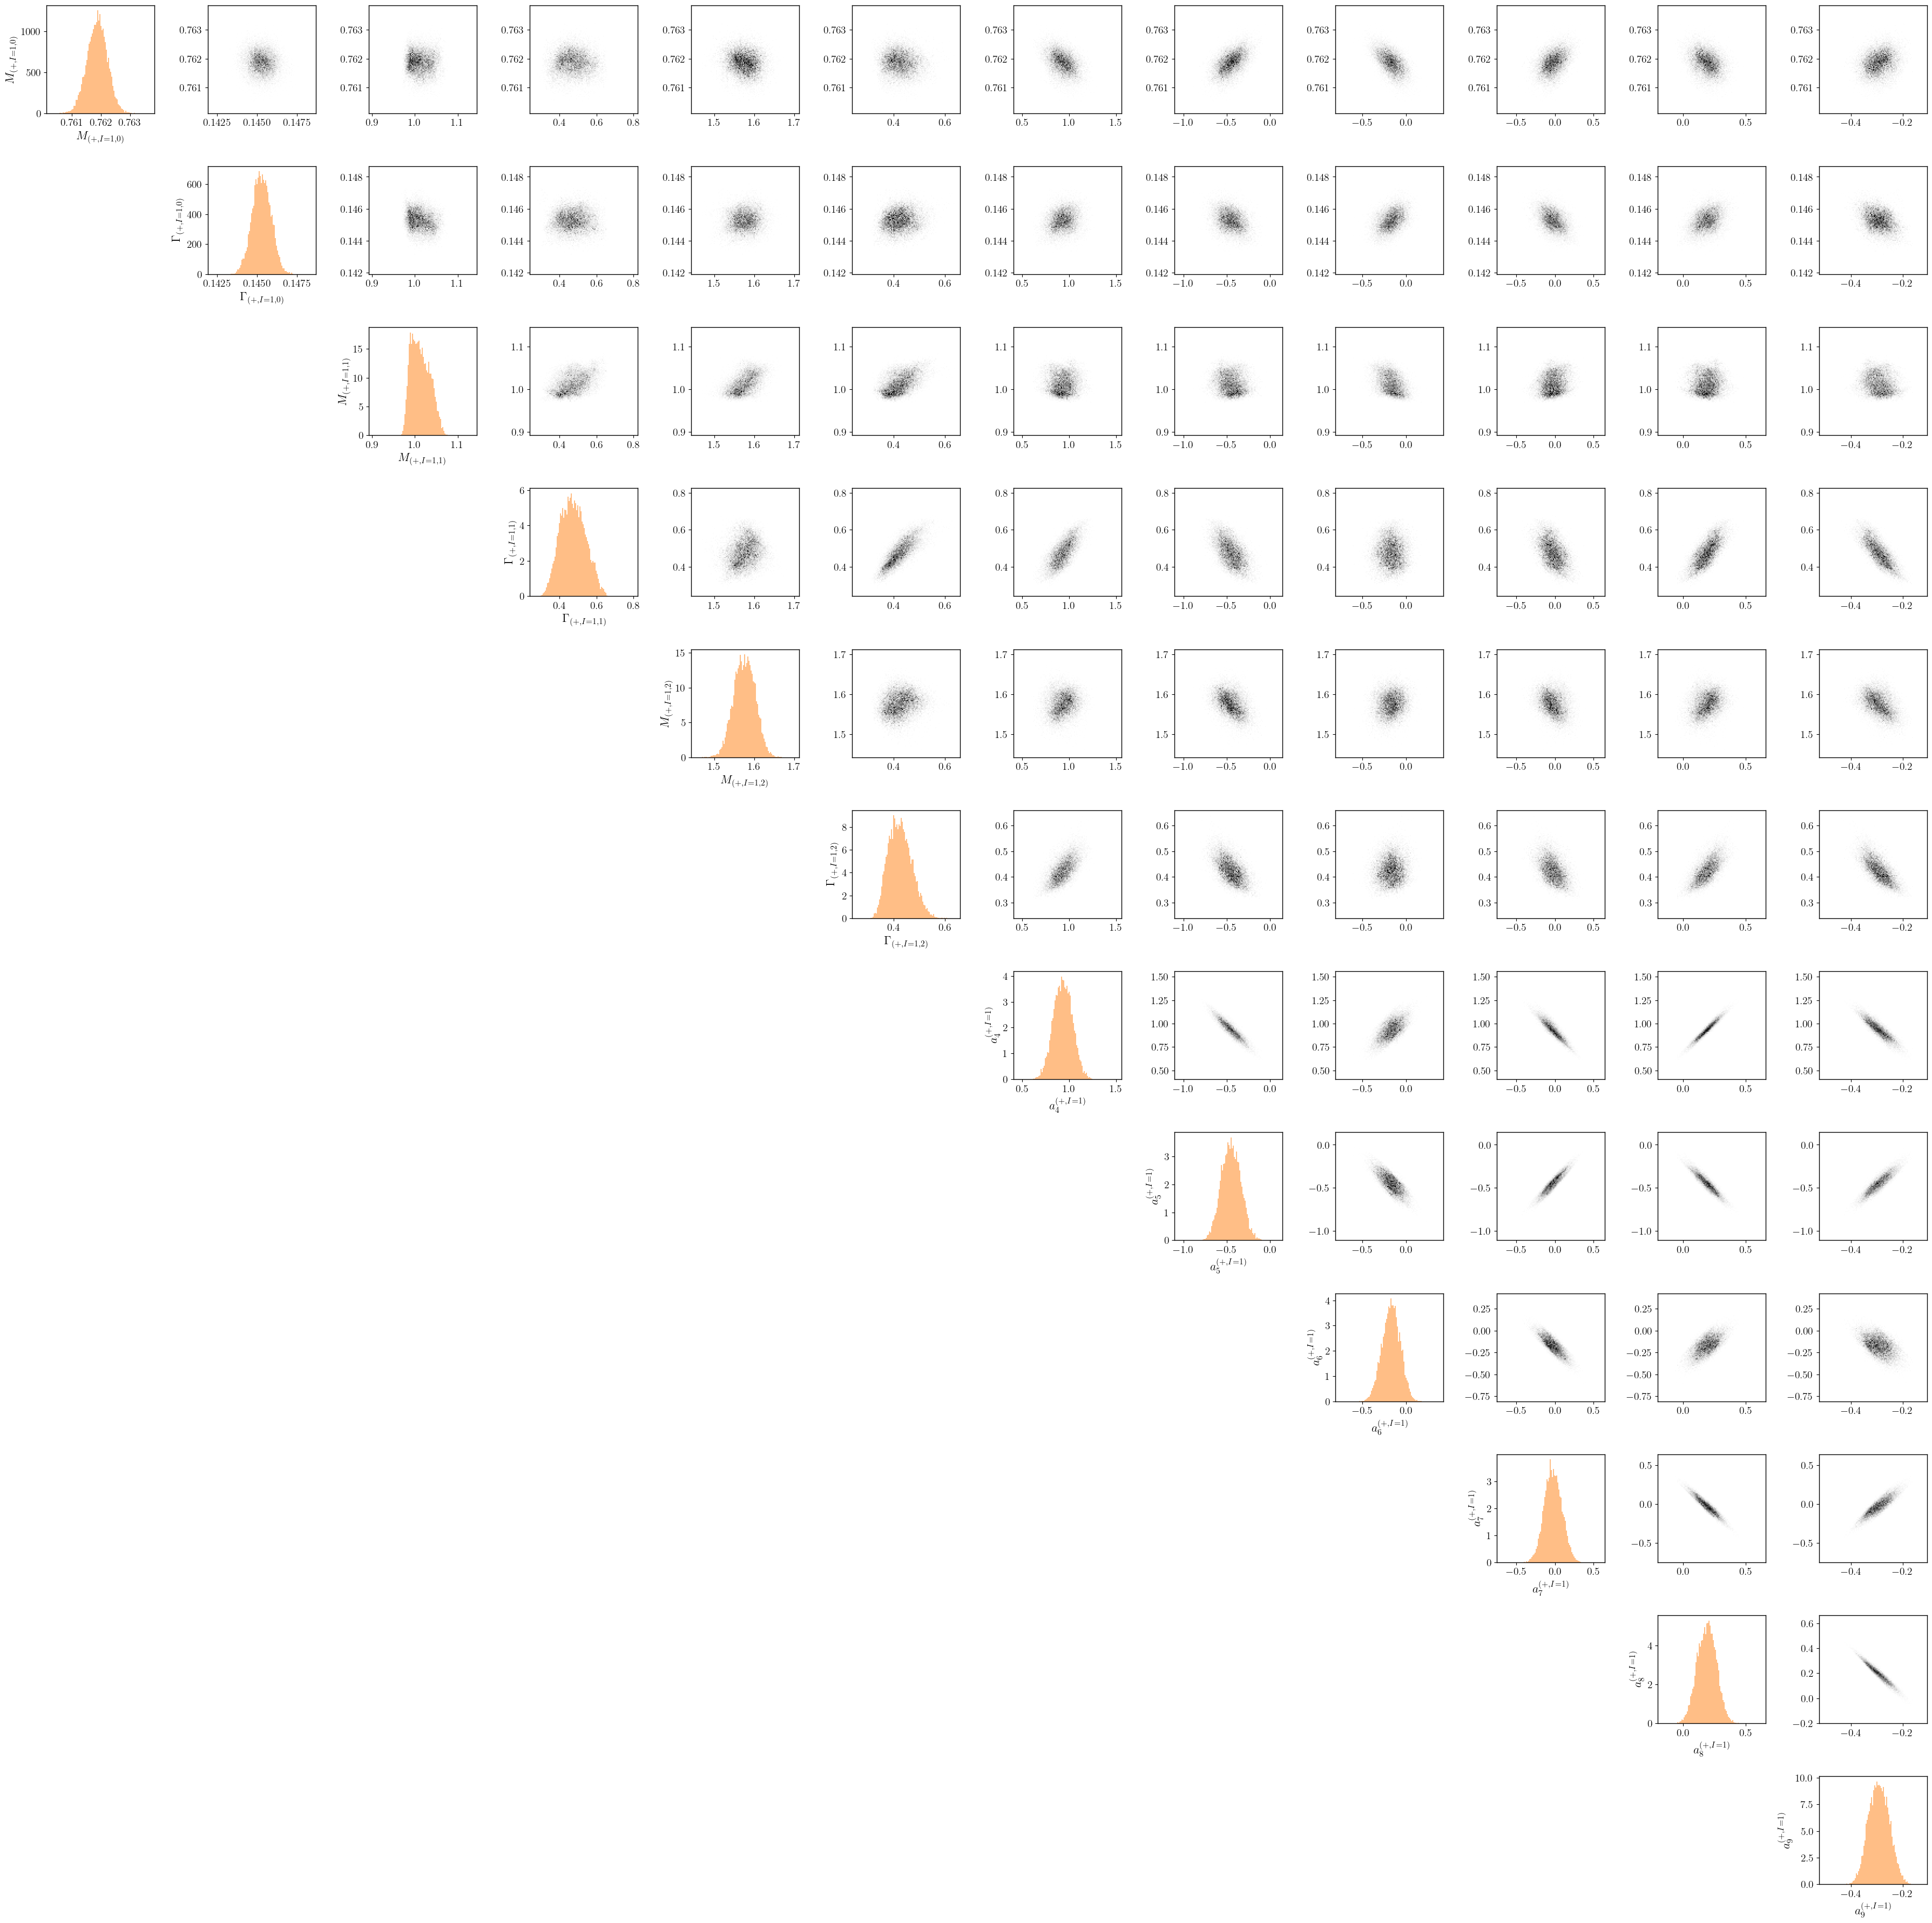

In [42]:
eos.tasks.corner_plot(af, posterior, base_directory=BASE_DIRECTORY)

In [45]:
print(f"rho mass  = {np.average(f.samples[:,0], weights=f.weights):.4f} ± {wstd(f.samples[:,0], weights=f.weights):.4f}")
print(f"rho width = {np.average(f.samples[:,1], weights=f.weights):.4f} ± {wstd(f.samples[:,1], weights=f.weights):.4f}")

print(f"rho' mass  = {np.average(f.samples[:,2], weights=f.weights):.4f} ± {wstd(f.samples[:,2], weights=f.weights):.4f}")
print(f"rho' width = {np.average(f.samples[:,3], weights=f.weights):.4f} ± {wstd(f.samples[:,3], weights=f.weights):.4f}")

print(f"rho'' mass  = {np.average(f.samples[:,4], weights=f.weights):.4f} ± {wstd(f.samples[:,4], weights=f.weights):.4f}")
print(f"rho'' width = {np.average(f.samples[:,5], weights=f.weights):.4f} ± {wstd(f.samples[:,5], weights=f.weights):.4f}")

rho mass  = 0.7619 ± 0.0003
rho width = 0.1453 ± 0.0006
rho' mass  = 1.0134 ± 0.0215
rho' width = 0.4750 ± 0.0672
rho'' mass  = 1.5752 ± 0.0266
rho'' width = 0.4262 ± 0.0448


In [51]:
eos.tasks.predict_observables(af, posterior, "a_0", base_directory=BASE_DIRECTORY)
eos.tasks.predict_observables(af, posterior, "a_1", base_directory=BASE_DIRECTORY)
eos.tasks.predict_observables(af, posterior, "a_2", base_directory=BASE_DIRECTORY)
eos.tasks.predict_observables(af, posterior, "a_3", base_directory=BASE_DIRECTORY)

Accordion(children=(Output(layout=Layout(height='200px', overflow='auto')),), titles=('data/FF-fp-I1-order9-3r…

Accordion(children=(Output(layout=Layout(height='200px', overflow='auto')),), titles=('data/FF-fp-I1-order9-3r…

Accordion(children=(Output(layout=Layout(height='200px', overflow='auto')),), titles=('data/FF-fp-I1-order9-3r…

Accordion(children=(Output(layout=Layout(height='200px', overflow='auto')),), titles=('data/FF-fp-I1-order9-3r…

In [52]:
a0 = eos.data.Prediction(os.path.join(BASE_DIRECTORY, 'data', posterior, 'pred-a_0'))
a1 = eos.data.Prediction(os.path.join(BASE_DIRECTORY, 'data', posterior, 'pred-a_1'))
a2 = eos.data.Prediction(os.path.join(BASE_DIRECTORY, 'data', posterior, 'pred-a_2'))
a3 = eos.data.Prediction(os.path.join(BASE_DIRECTORY, 'data', posterior, 'pred-a_3'))

In [59]:
coefficents_of_samples = np.column_stack([a0.samples, a1.samples, a2.samples, a3.samples,
                                                    f.samples[:,6], f.samples[:,7], f.samples[:,8], f.samples[:,9], f.samples[:,10], f.samples[:,11]])
np.shape(coefficents_of_samples)

(17962, 10)

In [60]:
coef_bfp = coefficents_of_samples[np.argmax(f.weights)]
coef_bfp

array([ 1.00605627, -1.15273876,  0.7082222 , -0.54743534,  0.85619027,
       -0.38747363, -0.18415785,  0.03681484,  0.13770564, -0.26252222])

In [61]:
params_bfp = f.samples[np.argmax(f.weights)]
params_bfp

array([ 0.76182712,  0.14571705,  1.00919436,  0.41810186,  1.55792429,
        0.39686836,  0.85619027, -0.38747363, -0.18415785,  0.03681484,
        0.13770564, -0.26252222])

In [67]:
# Dispersive bound computation
eos.tasks.predict_observables(af, posterior, "FF-fp-I1-dispersive-bound", base_directory=BASE_DIRECTORY)
preds = eos.data.Prediction(os.path.join(BASE_DIRECTORY, 'data', posterior, 'pred-FF-fp-I1-dispersive-bound'))

Accordion(children=(Output(layout=Layout(height='200px', overflow='auto')),), titles=('data/FF-fp-I1-order9/pr…

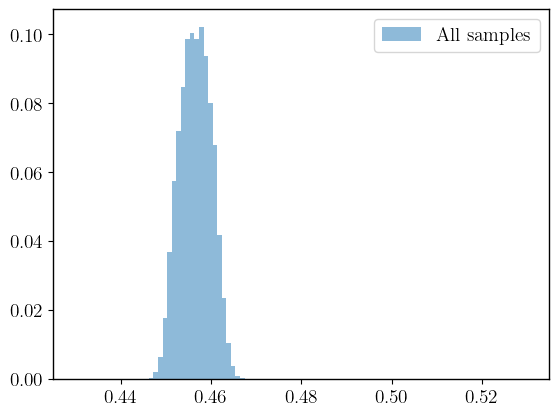

In [68]:
plt.hist(preds.samples, weights=preds.weights, bins=np.linspace(0.43,0.53,100), alpha=0.5, label='All samples')
plt.legend()
plt.show()

In [69]:
disp_values = np.array(preds.samples[:,0])
disp_mean   = np.average(disp_values, weights=preds.weights)
disp_std    = wstd(disp_values, weights=preds.weights)
print(f"Dispersive bound is {disp_mean:.4f} ± {disp_std:.4f}")

Dispersive bound is 0.4565 ± 0.0034


In [62]:
eos.tasks.predict_observables(af, posterior, "FF-fp2-I1-all", base_directory=BASE_DIRECTORY)

Accordion(children=(Output(layout=Layout(height='200px', overflow='auto')),), titles=('data/FF-fp-I1-order9-3r…

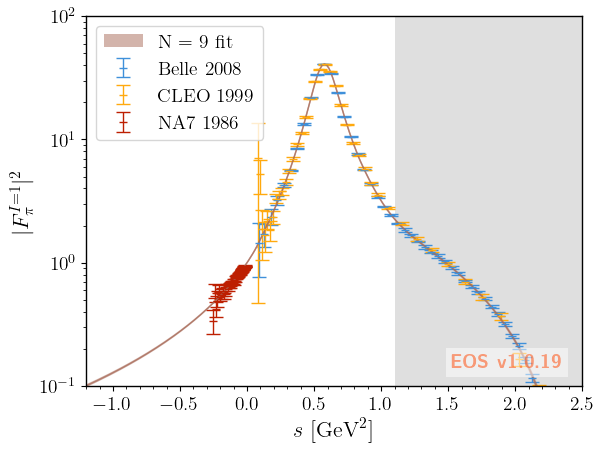

In [64]:
figure_args = {
'watermark': { 'position': 'lower right' },
'plot': {
    'xaxis': { 'label': '$s$', 'unit': '$\\mathrm{GeV}^2$', 'range': [-1.2, 2.5] },
    'yaxis': { 'label': r'$|F^{I=1}_\pi|^2$', 'range': [ 0.1, 100.0], 'scale': 'log' },
    'legend': { 'position': 'upper left' },
    'items': [
    { 'type': 'constraint', 'label': 'Belle 2008', 'color': colors[0],
        'variable': 'q2', 'observable': '0->pipi::Abs{f_+}^2(q2)',
        'constraints': '0->pipi::Abs{f_+}^2@Belle:2008C',
    },
    { 'type': 'constraint', 'label': 'CLEO 1999', 'color': colors[1],
        'variable': 'q2', 'observable': '0->pipi::Abs{f_+}^2(q2)',
        'constraints': '0->pipi::Abs{f_+}^2@CLEO:2000B',
    },
    { 'type': 'constraint', 'label': 'NA7 1986', 'color': colors[2],
        'variable': 'q2', 'observable': '0->pipi::Abs{f_+}^2(q2)',
        'constraints': '0->pipi::Abs{f_+}^2@NA7:1986A',
    },
    { 'type': 'uncertainty', 'label': 'N = 9 fit', 'color': colors[5],
        'variable': 'q2', 'range': [-1.2, 2.5], 'interpolation': 'cubic',
        'datafile': 'data/'+posterior+'/pred-FF-fp2-I1-all', 'resolution': 300
    },
    { 'type': 'band', 'color': 'gray', 'alpha': 0.25, 'x': [1.1, 2.5], 'y': [0.0, 100]}
    ]
}
}
figure = eos.figure.FigureFactory.from_dict(**figure_args)
figure.draw()

In [72]:
eos.tasks.predict_observables(af, posterior, "FF-arg-fp-I1-timelike", base_directory=BASE_DIRECTORY)

Accordion(children=(Output(layout=Layout(height='200px', overflow='auto')),), titles=('data/FF-fp-I1-order9/pr…

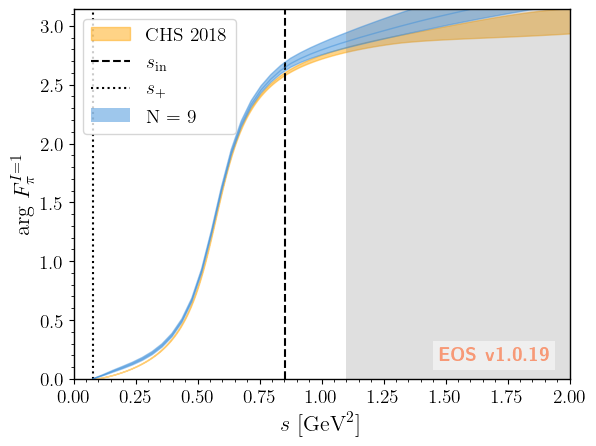

In [73]:
figure_args = {
  'watermark': { 'position': 'lower right' },
  'plot': {
    'xaxis': { 'label': '$s$', 'unit': '$\\mathrm{GeV}^2$', 'range': [0.0, 2.0] },
    'yaxis': { 'label': r'arg $F^{I=1}_\pi$', 'range': [0.0 , np.pi] },
    'legend': { 'position': 'upper left' },
    'items': [
      { 'type': 'uncertainty', 'label': 'N = 9', 'interpolation': 'cubic', 'resolution': 250,
        'variable': 'q2', 'datafile': 'data/'+posterior+'/pred-FF-arg-fp-I1-timelike', 'color': colors[0]
      },
      { 'type': 'band', 'color': 'gray', 'alpha': 0.25, 'x': [1.1, 2.0], 'y': [0.0, np.pi]}
    ]
  }
}
figure = eos.figure.FigureFactory.from_dict(**figure_args)

q2_over_mpisquared, phase, err = np.loadtxt("scripts/d11-central.txt", skiprows=1, unpack=True)
mpi = eos.Parameters()["mass::pi^+"].evaluate()
q2  = q2_over_mpisquared * mpi**2

figure._ax.fill_between(q2, phase-err, phase+err, label="CHS 2018", alpha=0.5, color=colors[1])
figure._ax.plot([sIn, sIn], [0.0, np.pi], color='k', linestyle='--', label= r'$s_\mathrm{in}$')
figure._ax.plot([sPlus, sPlus], [0.0, np.pi], color='k', linestyle=':', label= r'$s_+$')
figure._ax.legend(loc="upper left")

figure.draw()

In [74]:
get_gof(analysis, start_point)
analysis.parameters.dump('data/'+posterior+'/mode-default/parameters.yaml')

Handling item to plot 0->pipi::Arg{f_+}(Re{psi},Im{psi})@BHKMNR2026 in the complex plane
Overriding parameters from file
[parameters.override] Overriding existing parameter '0->Kpi::Gamma_(+,0)@KSvD2025' with central value '0'
[parameters.override] Overriding existing parameter '0->Kpi::Gamma_(+,1)@KSvD2025' with central value '0'
[parameters.override] Overriding existing parameter '0->Kpi::Gamma_(+,2)@KSvD2025' with central value '0'
[parameters.override] Overriding existing parameter '0->Kpi::Gamma_(0,0)@KSvD2025' with central value '0'
[parameters.override] Overriding existing parameter '0->Kpi::Gamma_(0,1)@KSvD2025' with central value '0'
[parameters.override] Overriding existing parameter '0->Kpi::M_(+,0)@KSvD2025' with central value '0'
[parameters.override] Overriding existing parameter '0->Kpi::M_(+,1)@KSvD2025' with central value '0'
[parameters.override] Overriding existing parameter '0->Kpi::M_(+,2)@KSvD2025' with central value '0'
[parameters.override] Overriding existing p

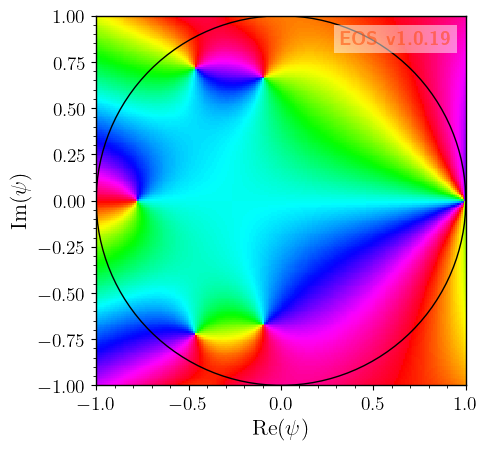

In [75]:
figure_args = {
'plot': {
    'xaxis': { 'label': r'$\mathrm{Re}(\psi)$', 'range': [-1.0, 1.0] },
    'yaxis': { 'label': r'$\mathrm{Im}(\psi)$', 'range': [-1.0, 1.0] },
    # 'legend': { 'position': 'upper left' },
    'items': [
    { 'type': 'complex-plane', 'label': 'N = 9 fit', 'colormap': 'hsv',
        'variables': ["Re{psi}", "Im{psi}"], 'observable': "0->pipi::Arg{f_+}(Re{psi},Im{psi})@BHKMNR2026",
        'fixed_parameters_from_file': 'data/'+posterior+'/mode-default/parameters.yaml', 'resolution': 200
    }
    ]
}
}
figure = eos.figure.FigureFactory.from_dict(**figure_args)
figure.draw()
circle = plt.Circle((0, 0), 1.0, color='k', fill=False)
figure._ax.add_patch(circle)
figure._ax.set_aspect("equal", adjustable="box")


In [76]:
eos.tasks.predict_observables(af, posterior, "real-partial-wave-I1", base_directory=BASE_DIRECTORY)
eos.tasks.predict_observables(af, posterior, "imag-partial-wave-I1", base_directory=BASE_DIRECTORY)

Accordion(children=(Output(layout=Layout(height='200px', overflow='auto')),), titles=('data/FF-fp-I1-order9/pr…

Accordion(children=(Output(layout=Layout(height='200px', overflow='auto')),), titles=('data/FF-fp-I1-order9/pr…

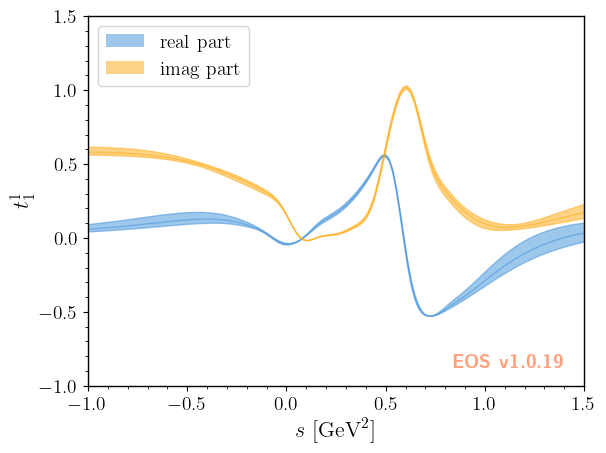

In [77]:
figure_args = {
  'watermark': { 'position': 'lower right' },
  'plot': {
    'xaxis': { 'label': '$s$', 'unit': '$\\mathrm{GeV}^2$', 'range': [-1.0, 1.5] },
    'yaxis': { 'label': '$t_1^1$',  'range': [-1.0, 1.5]},
    'legend': { 'position': 'upper left' },
    'items': [
      { 'type': 'uncertainty', 'label': 'real part', 'interpolation': 'cubic', 'resolution': 250,
        'variable': 'q2', 'datafile': 'data/'+posterior+'/pred-real-partial-wave-I1'
      },
      { 'type': 'uncertainty', 'label': 'imag part', 'interpolation': 'cubic', 'resolution': 250,
        'variable': 'q2', 'datafile': 'data/'+posterior+'/pred-imag-partial-wave-I1'
      },
    ]
  }
}
figure = eos.figure.FigureFactory.from_dict(**figure_args)
figure.draw()

In [78]:
# Analytic value of a11
eos.tasks.predict_observables(af, posterior, "FF-fp-I1-scattering-length-params", base_directory=BASE_DIRECTORY)
sl_params = eos.data.Prediction(os.path.join(BASE_DIRECTORY, 'data', posterior, 'pred-FF-fp-I1-scattering-length-params'))

Accordion(children=(Output(layout=Layout(height='200px', overflow='auto')),), titles=('data/FF-fp-I1-order9/pr…

In [79]:
a11_values = np.array(list(map(a11_calculator, sl_params.samples)))* mpi**2
a11_mean   = np.average(a11_values, weights=sl_params.weights)
a11_std    = wstd(a11_values, weights=sl_params.weights)
print(f"a11 = {a11_mean:.4f} ± {a11_std:.4f}")

a11 = 0.0336 ± 0.0053


In [80]:
# Charge radius
eos.tasks.predict_observables(af, posterior, "FF-fp-I1-pion-charge-radius-param", base_directory=BASE_DIRECTORY)
fprime_values = eos.data.Prediction(os.path.join(BASE_DIRECTORY, 'data', posterior, 'pred-FF-fp-I1-pion-charge-radius-param'))

Accordion(children=(Output(layout=Layout(height='200px', overflow='auto')),), titles=('data/FF-fp-I1-order9/pr…

In [81]:
charge_radius_squared_values = np.array(list(map(charge_radius_squared_calculator, fprime_values.samples[:, 0])))
radius_mean  = np.average(charge_radius_squared_values, weights=fprime_values.weights)
radius_std   = wstd(charge_radius_squared_values, weights=fprime_values.weights)

print(f"<r^2> = {radius_mean:.4f} ± {radius_std:.4f} fm^2")

<r^2> = 0.4434 ± 0.0060 fm^2


In [82]:
# Residue at the rho pole
eos.tasks.predict_observables(af, posterior, "re-rho-residue-psi", base_directory=BASE_DIRECTORY)
re_res_psi = eos.data.Prediction(os.path.join(BASE_DIRECTORY, 'data', posterior, 'pred-re-rho-residue-psi'))
eos.tasks.predict_observables(af, posterior, "im-rho-residue-psi", base_directory=BASE_DIRECTORY)
im_res_psi = eos.data.Prediction(os.path.join(BASE_DIRECTORY, 'data', posterior, 'pred-im-rho-residue-psi'))

Accordion(children=(Output(layout=Layout(height='200px', overflow='auto')),), titles=('data/FF-fp-I1-order9/pr…

Accordion(children=(Output(layout=Layout(height='200px', overflow='auto')),), titles=('data/FF-fp-I1-order9/pr…

In [83]:
re_res = re_res_psi.samples[:,0]
im_res = im_res_psi.samples[:,0]
M      = f.samples[:,0]
Gamma  = f.samples[:,1]

print(len(re_res), len(im_res), len(M), len(Gamma)) # check that they have the same length

15317 15317 15317 15317


In [119]:
data = []

for r, i, m, g in zip(re_res, im_res, M, Gamma):
    data.append([r, i, m, g])

with open("residues_psi_order9.wl", "w") as file:
    lines = [f"{{{r}, {i}, {m}, {g}}}" for r, i, m, g in data]
    file.write("{\n" + ",\n".join(lines) + "\n}")

In [120]:
with open("residues_s_order9.wl") as file:
    text = file.read()

# Replace Mathematica braces with Python brackets
text = text.replace("{", "[").replace("}", "]")

data = ast.literal_eval(text)

In [121]:
res_s       = np.array([re + 1j * im for re, im in data])
res_s_mean  = np.average(res_s, weights=f.weights)
radius_std  = wstd(res_s, weights=f.weights)
print(f"residue at s_rho is ({np.real(res_s_mean):.4f} ± {np.real(radius_std):.4f}) + i * ({np.imag(res_s_mean):.4f} ± {np.imag(radius_std):.4f})")

residue at s_rho is (-0.7666 ± 0.0135) + i * (0.3188 ± 0.0188)


In [122]:
# Computing g_{rho pi pi} and g_{rho gamma}
f_at_s_rho       = np.array([get_f_rho(s, analysis) for s in f.samples])
f_at_s_rho_value = f_at_s_rho[:,0] + 1j * f_at_s_rho[:,1]

In [123]:
s_rho       = (M - 1j * Gamma / 2)**2
g_rho_gamma = np.sqrt(24j * np.pi * s_rho / f_at_s_rho_value / res_s / (np.sqrt(1 - sPlus / s_rho))**3)
g_rho_pi_pi = - res_s / s_rho * g_rho_gamma

In [124]:
g_rho_gamma_mean = np.average(g_rho_gamma, weights=f.weights)
g_rho_gamma_std  = wstd(g_rho_gamma, weights=f.weights)
print(f"g_rho_gamma =  ({np.real(g_rho_gamma_mean):.4f} ± {np.real(g_rho_gamma_std):.4f}) + i * ({np.imag(g_rho_gamma_mean):.4f} ± {np.imag(g_rho_gamma_std):.4f})")

g_rho_pi_pi_mean = np.average(g_rho_pi_pi, weights=f.weights)
g_rho_pi_pi_std  = wstd(g_rho_pi_pi, weights=f.weights)
print(f"g_rho_pi_pi =  ({np.real(g_rho_pi_pi_mean):.4f} ± {np.real(g_rho_pi_pi_std):.4f}) + i * ({np.imag(g_rho_pi_pi_mean):.4f} ± {np.imag(g_rho_pi_pi_std):.4f})")

g_rho_gamma =  (4.5278 ± 0.0024) + i * (0.2066 ± -0.0096)
g_rho_pi_pi =  (6.3753 ± 0.0710) + i * (-1.0189 ± 0.1670)


## N = 9, 3 resonances, manual constraint


In [11]:
posterior = 'FF-fp-I1-order9-3resonances-manual-constraint'
analysis  = af.analysis(posterior)

Creating analysis with 12 priors, 3 EOS-wide constraints, 2 global options, 3 manually-entered constraints and 2 fixed parameters.
likelihood probably depends on 5 parameter(s) that do not appear in the prior; check prior?


In [12]:
start_point = [0.76197356,  0.14474252,  1.00682738,  0.33391783,  1.54172024,
        0.36689259,  0.72458606, -0.24576206, -0.26145234,  0.19197991,
        0.02447067, -0.2002633]

In [13]:
get_gof(analysis, start_point)

In [14]:
#bfp, gof = eos.tasks.find_mode(af, posterior, start_point=start_point, base_directory=BASE_DIRECTORY, optimizations=100)
bfp, gof = eos.tasks.find_mode(af, posterior, importance_samples=True, base_directory=BASE_DIRECTORY, optimizations=100)
display(gof)
bfp.point

Accordion(children=(Output(layout=Layout(height='200px', overflow='auto')),), titles=('data/FF-fp-I1-order9-3r…

array([ 0.76268359,  0.14430508,  0.96427102,  0.1628936 ,  1.46272391,
        0.33071623,  0.4031402 ,  0.15598225, -0.46246522,  0.51057825,
       -0.22778974, -0.05921595])

In [15]:
if resample:
    eos.tasks.sample_nested(af, posterior, base_directory=BASE_DIRECTORY, bound='multi', nlive=200)

f = eos.data.ImportanceSamples(os.path.join(BASE_DIRECTORY, 'data', posterior, 'samples'))
print(f"Collected {f.samples.shape[0]} samples")

Collected 16447 samples


In [16]:
for i, p in enumerate(analysis.varied_parameters):
    mean = np.average(f.samples[:,i], weights=f.weights)
    std  = wstd(f.samples[:,i], weights=f.weights)
    print(f"      - {{ 'parameter': '{p.name()}', 'min':  {mean - 5*std:.5f}, 'max':  {mean + 5*std:.5f}, 'type': 'uniform'}}")

      - { 'parameter': '0->pipi::M_(+,1,0)@BHKMNR2026', 'min':  0.76147, 'max':  0.76449, 'type': 'uniform'}
      - { 'parameter': '0->pipi::Gamma_(+,1,0)@BHKMNR2026', 'min':  0.14152, 'max':  0.14679, 'type': 'uniform'}
      - { 'parameter': '0->pipi::M_(+,1,1)@BHKMNR2026', 'min':  0.92963, 'max':  1.11880, 'type': 'uniform'}
      - { 'parameter': '0->pipi::Gamma_(+,1,1)@BHKMNR2026', 'min':  0.02558, 'max':  0.48870, 'type': 'uniform'}
      - { 'parameter': '0->pipi::M_(+,1,2)@BHKMNR2026', 'min':  1.39589, 'max':  1.62226, 'type': 'uniform'}
      - { 'parameter': '0->pipi::Gamma_(+,1,2)@BHKMNR2026', 'min':  0.24260, 'max':  0.44931, 'type': 'uniform'}
      - { 'parameter': '0->pipi::a_(+,1)^4@BHKMNR2026', 'min':  0.28228, 'max':  0.57241, 'type': 'uniform'}
      - { 'parameter': '0->pipi::a_(+,1)^5@BHKMNR2026', 'min':  -0.07467, 'max':  0.27093, 'type': 'uniform'}
      - { 'parameter': '0->pipi::a_(+,1)^6@BHKMNR2026', 'min':  -0.89772, 'max':  -0.27383, 'type': 'uniform'}
    

Accordion(children=(Output(layout=Layout(height='200px', overflow='auto')),), titles=('data/FF-fp-I1-order9-3r…

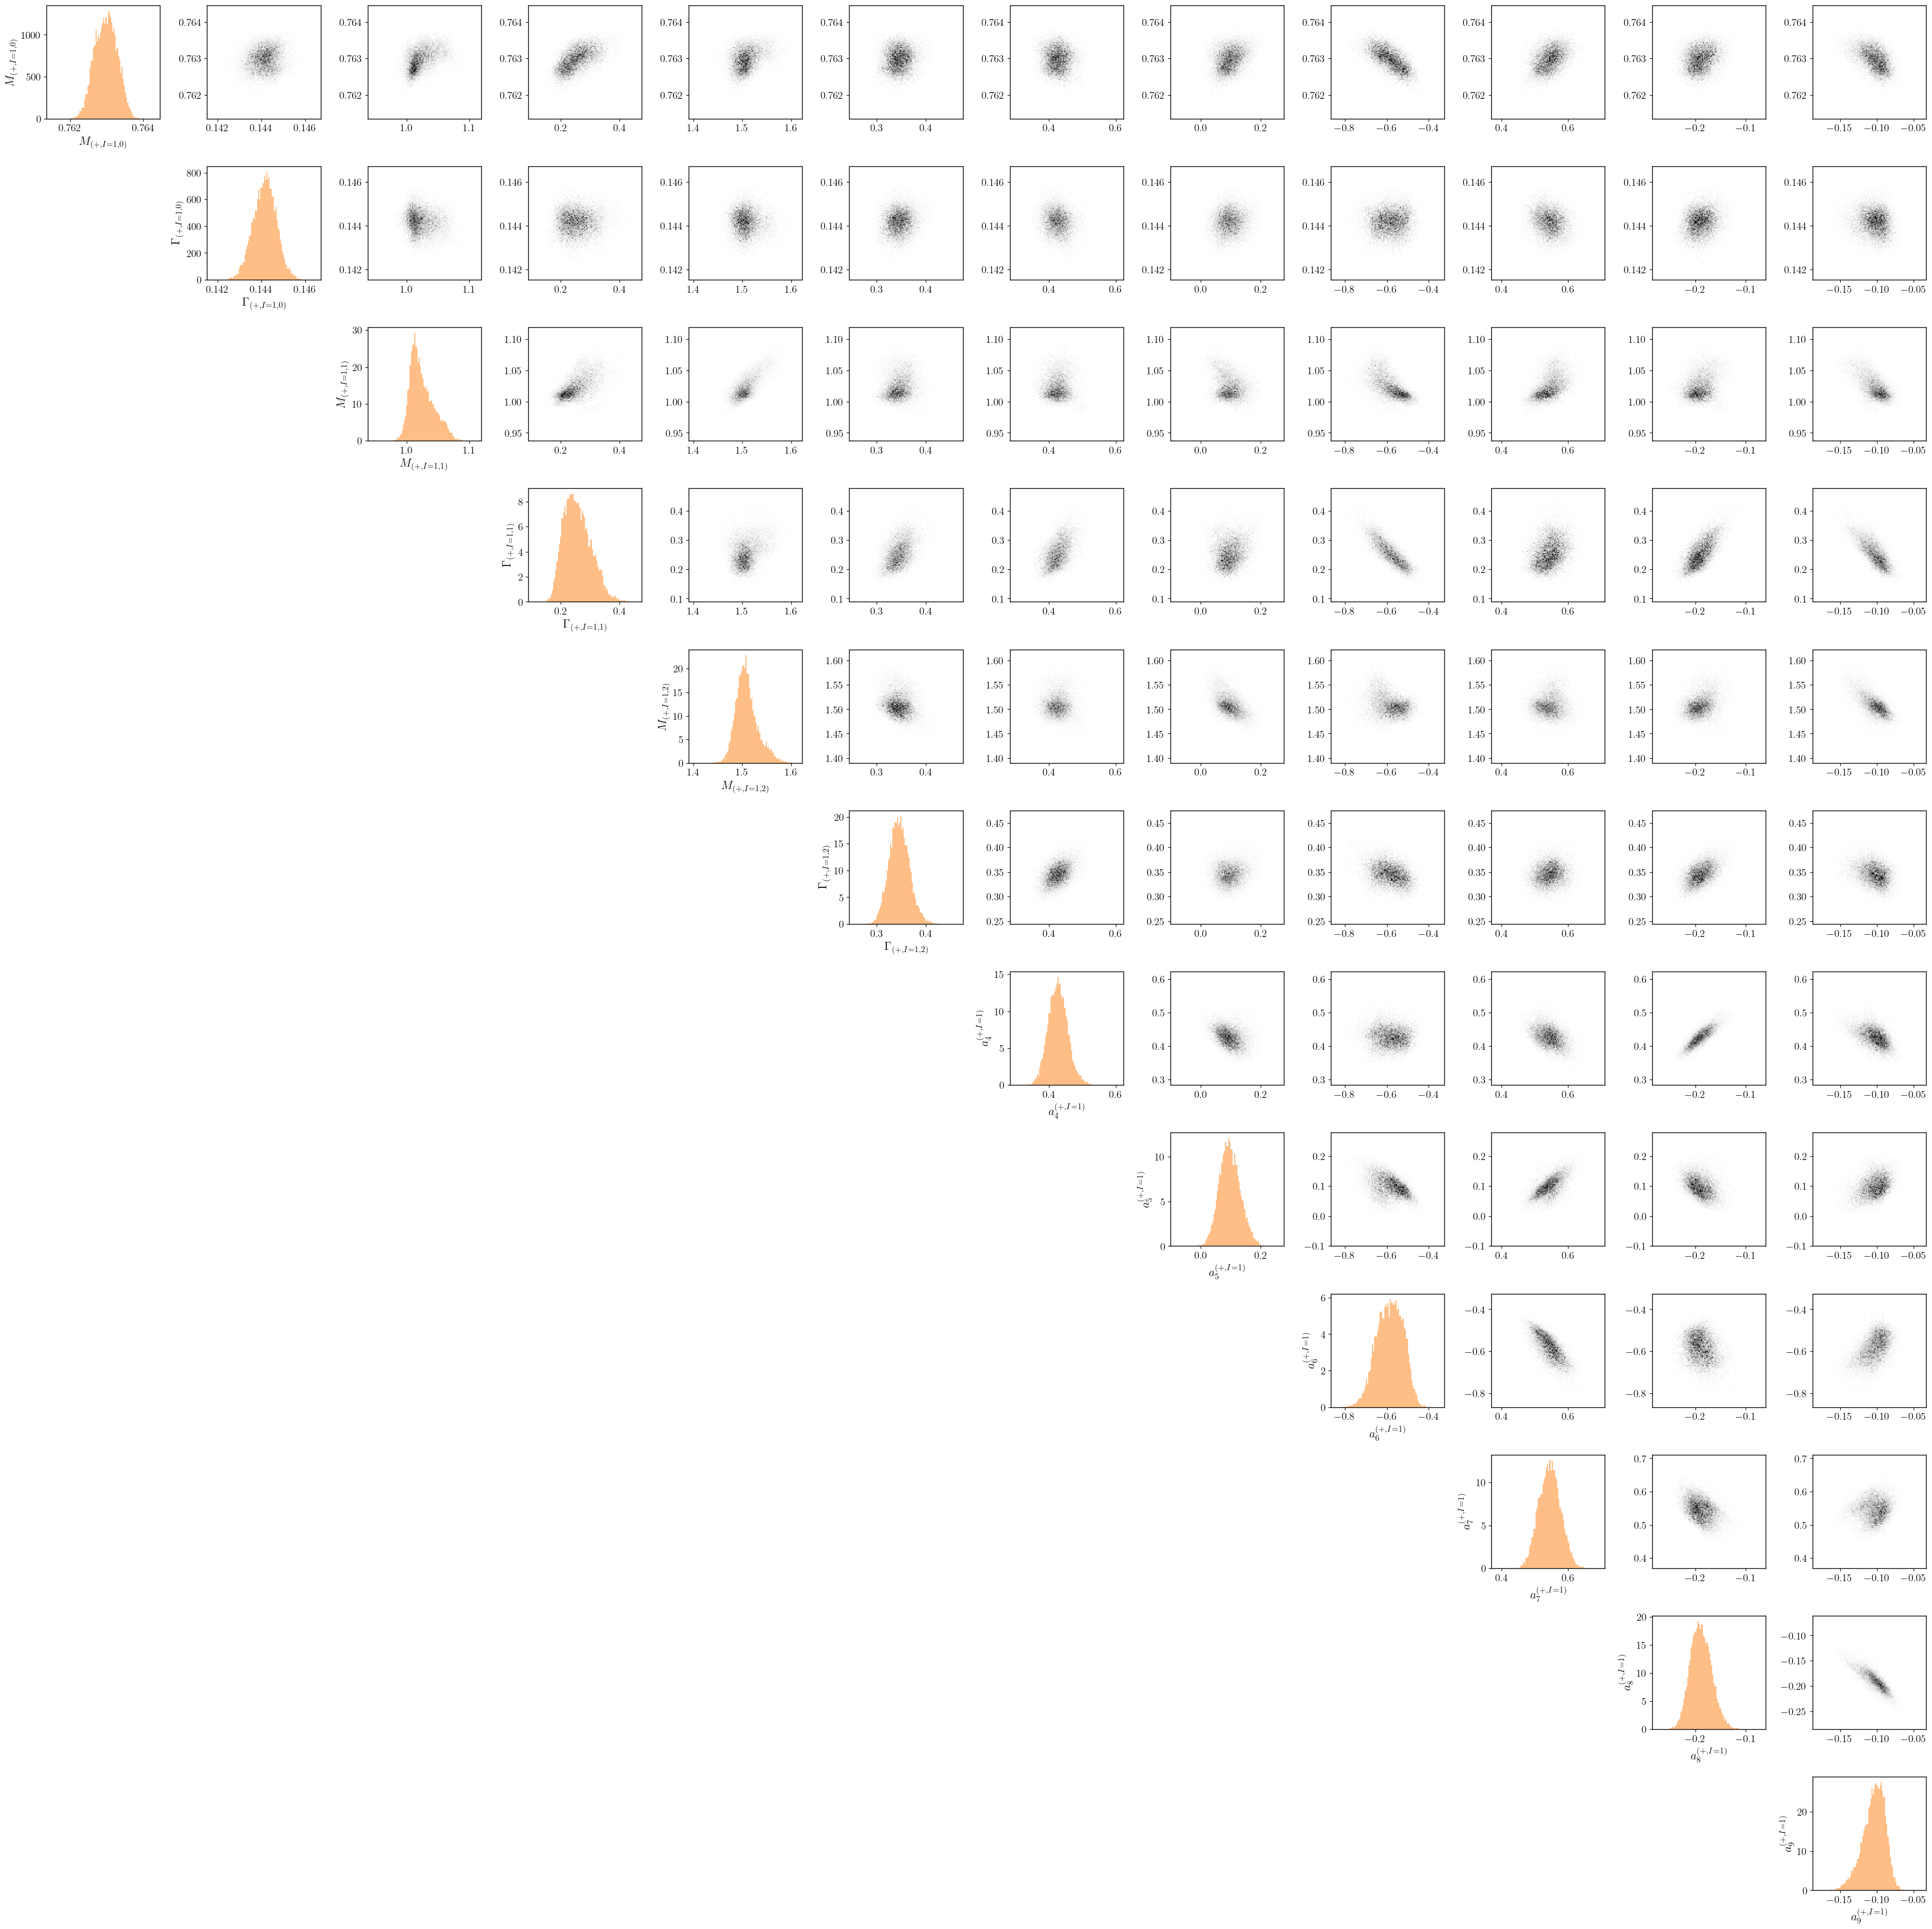

In [17]:
eos.tasks.corner_plot(af, posterior, base_directory=BASE_DIRECTORY)

In [18]:
print(f"rho mass  = {np.average(f.samples[:,0], weights=f.weights):.4f} ± {wstd(f.samples[:,0], weights=f.weights):.4f}")
print(f"rho width = {np.average(f.samples[:,1], weights=f.weights):.4f} ± {wstd(f.samples[:,1], weights=f.weights):.4f}")

print(f"rho' mass  = {np.average(f.samples[:,2], weights=f.weights):.4f} ± {wstd(f.samples[:,2], weights=f.weights):.4f}")
print(f"rho' width = {np.average(f.samples[:,3], weights=f.weights):.4f} ± {wstd(f.samples[:,3], weights=f.weights):.4f}")

print(f"rho'' mass  = {np.average(f.samples[:,4], weights=f.weights):.4f} ± {wstd(f.samples[:,4], weights=f.weights):.4f}")
print(f"rho'' width = {np.average(f.samples[:,5], weights=f.weights):.4f} ± {wstd(f.samples[:,5], weights=f.weights):.4f}")

rho mass  = 0.7630 ± 0.0003
rho width = 0.1442 ± 0.0005
rho' mass  = 1.0242 ± 0.0189
rho' width = 0.2571 ± 0.0463
rho'' mass  = 1.5091 ± 0.0226
rho'' width = 0.3460 ± 0.0207


In [19]:
eos.tasks.predict_observables(af, posterior, "a_0", base_directory=BASE_DIRECTORY)
eos.tasks.predict_observables(af, posterior, "a_1", base_directory=BASE_DIRECTORY)
eos.tasks.predict_observables(af, posterior, "a_2", base_directory=BASE_DIRECTORY)
eos.tasks.predict_observables(af, posterior, "a_3", base_directory=BASE_DIRECTORY)

Accordion(children=(Output(layout=Layout(height='200px', overflow='auto')),), titles=('data/FF-fp-I1-order9-3r…

Accordion(children=(Output(layout=Layout(height='200px', overflow='auto')),), titles=('data/FF-fp-I1-order9-3r…

Accordion(children=(Output(layout=Layout(height='200px', overflow='auto')),), titles=('data/FF-fp-I1-order9-3r…

Accordion(children=(Output(layout=Layout(height='200px', overflow='auto')),), titles=('data/FF-fp-I1-order9-3r…

In [20]:
a0 = eos.data.Prediction(os.path.join(BASE_DIRECTORY, 'data', posterior, 'pred-a_0'))
a1 = eos.data.Prediction(os.path.join(BASE_DIRECTORY, 'data', posterior, 'pred-a_1'))
a2 = eos.data.Prediction(os.path.join(BASE_DIRECTORY, 'data', posterior, 'pred-a_2'))
a3 = eos.data.Prediction(os.path.join(BASE_DIRECTORY, 'data', posterior, 'pred-a_3'))

In [21]:
coefficents_of_samples = np.column_stack([a0.samples, a1.samples, a2.samples, a3.samples,
                                                    f.samples[:,6], f.samples[:,7], f.samples[:,8], f.samples[:,9], f.samples[:,10], f.samples[:,11]])
np.shape(coefficents_of_samples)

(16447, 10)

In [22]:
coef_bfp = coefficents_of_samples[np.argmax(f.weights)]
coef_bfp

array([ 0.77488813, -0.93773424,  0.71578544, -0.36501696,  0.37377351,
        0.14443081, -0.61731059,  0.58574114, -0.22790117, -0.08948921])

In [23]:
params_bfp = f.samples[np.argmax(f.weights)]
params_bfp

array([ 0.76321675,  0.1438999 ,  1.02106036,  0.22875944,  1.51677498,
        0.30795311,  0.37377351,  0.14443081, -0.61731059,  0.58574114,
       -0.22790117, -0.08948921])

In [24]:
# Dispersive bound computation
eos.tasks.predict_observables(af, posterior, "FF-fp-I1-dispersive-bound", base_directory=BASE_DIRECTORY)
preds = eos.data.Prediction(os.path.join(BASE_DIRECTORY, 'data', posterior, 'pred-FF-fp-I1-dispersive-bound'))

Accordion(children=(Output(layout=Layout(height='200px', overflow='auto')),), titles=('data/FF-fp-I1-order9-3r…

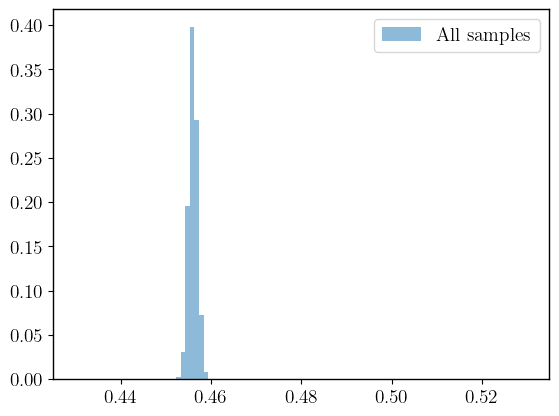

In [25]:
plt.hist(preds.samples, weights=preds.weights, bins=np.linspace(0.43,0.53,100), alpha=0.5, label='All samples')
plt.legend()
plt.show()

In [26]:
disp_values = np.array(preds.samples[:,0])
disp_mean   = np.average(disp_values, weights=preds.weights)
disp_std    = wstd(disp_values, weights=preds.weights)
print(f"Dispersive bound is {disp_mean:.4f} ± {disp_std:.4f}")

Dispersive bound is 0.4560 ± 0.0009


In [27]:
eos.tasks.predict_observables(af, posterior, "FF-fp2-I1-all", base_directory=BASE_DIRECTORY)

Accordion(children=(Output(layout=Layout(height='200px', overflow='auto')),), titles=('data/FF-fp-I1-order9-3r…

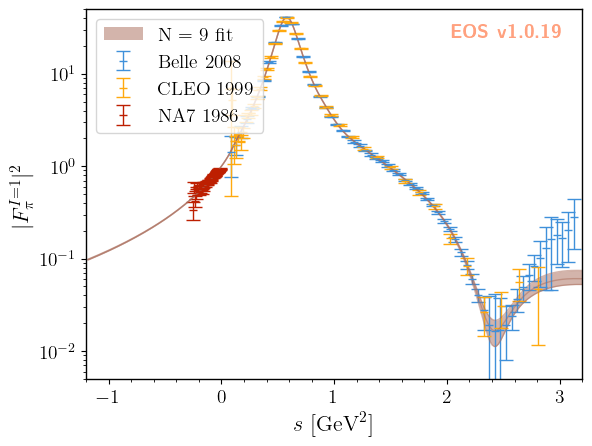

In [28]:
figure_args = {
'watermark': { 'position': 'upper right' },
'plot': {
    'xaxis': { 'label': '$s$', 'unit': '$\\mathrm{GeV}^2$', 'range': [-1.2, 3.2] },
    'yaxis': { 'label': r'$|F^{I=1}_\pi|^2$', 'range': [ 0.005, 50.0], 'scale': 'log' },
    'legend': { 'position': 'upper left' },
    'items': [
    { 'type': 'constraint', 'label': 'Belle 2008', 'color': colors[0],
        'variable': 'q2', 'observable': '0->pipi::Abs{f_+}^2(q2)',
        'constraints': '0->pipi::Abs{f_+}^2@Belle:2008C',
    },
    { 'type': 'constraint', 'label': 'CLEO 1999', 'color': colors[1],
        'variable': 'q2', 'observable': '0->pipi::Abs{f_+}^2(q2)',
        'constraints': '0->pipi::Abs{f_+}^2@CLEO:2000B',
    },
    { 'type': 'constraint', 'label': 'NA7 1986', 'color': colors[2],
        'variable': 'q2', 'observable': '0->pipi::Abs{f_+}^2(q2)',
        'constraints': '0->pipi::Abs{f_+}^2@NA7:1986A',
    },
    { 'type': 'uncertainty', 'label': 'N = 9 fit', 'color': colors[5],
        'variable': 'q2', 'range': [-1.2, 3.2], 'interpolation': 'cubic',
        'datafile': 'data/'+posterior+'/pred-FF-fp2-I1-all', 'resolution': 300
    },
    # { 'type': 'band', 'color': 'gray', 'alpha': 0.25, 'x': [1.1, 2.5], 'y': [0.0, 100]}
    ]
}
}
figure = eos.figure.FigureFactory.from_dict(**figure_args)
figure.draw()

In [29]:
eos.tasks.predict_observables(af, posterior, "FF-arg-fp-I1-timelike", base_directory=BASE_DIRECTORY)

Accordion(children=(Output(layout=Layout(height='200px', overflow='auto')),), titles=('data/FF-fp-I1-order9-3r…

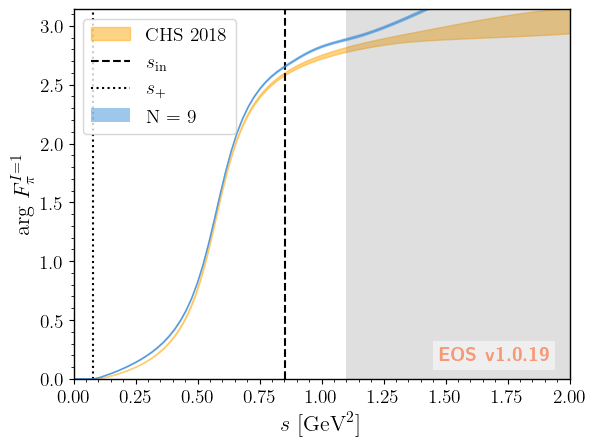

In [30]:
figure_args = {
  'watermark': { 'position': 'lower right' },
  'plot': {
    'xaxis': { 'label': '$s$', 'unit': '$\\mathrm{GeV}^2$', 'range': [0.0, 2.0] },
    'yaxis': { 'label': r'arg $F^{I=1}_\pi$', 'range': [0.0 , np.pi] },
    'legend': { 'position': 'upper left' },
    'items': [
      { 'type': 'uncertainty', 'label': 'N = 9', 'interpolation': 'cubic', 'resolution': 250,
        'variable': 'q2', 'datafile': 'data/'+posterior+'/pred-FF-arg-fp-I1-timelike', 'color': colors[0]
      },
      { 'type': 'band', 'color': 'gray', 'alpha': 0.25, 'x': [1.1, 2.0], 'y': [0.0, np.pi]}
    ]
  }
}
figure = eos.figure.FigureFactory.from_dict(**figure_args)

q2_over_mpisquared, phase, err = np.loadtxt("scripts/d11-central.txt", skiprows=1, unpack=True)
mpi = eos.Parameters()["mass::pi^+"].evaluate()
q2  = q2_over_mpisquared * mpi**2

figure._ax.fill_between(q2, phase-err, phase+err, label="CHS 2018", alpha=0.5, color=colors[1])
figure._ax.plot([sIn, sIn], [0.0, np.pi], color='k', linestyle='--', label= r'$s_\mathrm{in}$')
figure._ax.plot([sPlus, sPlus], [0.0, np.pi], color='k', linestyle=':', label= r'$s_+$')
figure._ax.legend(loc="upper left")

figure.draw()

In [ ]:
get_gof(analysis, start_point)
analysis.parameters.dump('data/'+posterior+'/mode-default/parameters.yaml')

Handling item to plot 0->pipi::Arg{f_+}(Re{psi},Im{psi})@BHKMNR2026 in the complex plane
Overriding parameters from file
[parameters.override] Overriding existing parameter '0->Kpi::Gamma_(+,0)@KSvD2025' with central value '0'
[parameters.override] Overriding existing parameter '0->Kpi::Gamma_(+,1)@KSvD2025' with central value '0'
[parameters.override] Overriding existing parameter '0->Kpi::Gamma_(+,2)@KSvD2025' with central value '0'
[parameters.override] Overriding existing parameter '0->Kpi::Gamma_(0,0)@KSvD2025' with central value '0'
[parameters.override] Overriding existing parameter '0->Kpi::Gamma_(0,1)@KSvD2025' with central value '0'
[parameters.override] Overriding existing parameter '0->Kpi::M_(+,0)@KSvD2025' with central value '0'
[parameters.override] Overriding existing parameter '0->Kpi::M_(+,1)@KSvD2025' with central value '0'
[parameters.override] Overriding existing parameter '0->Kpi::M_(+,2)@KSvD2025' with central value '0'
[parameters.override] Overriding existing p

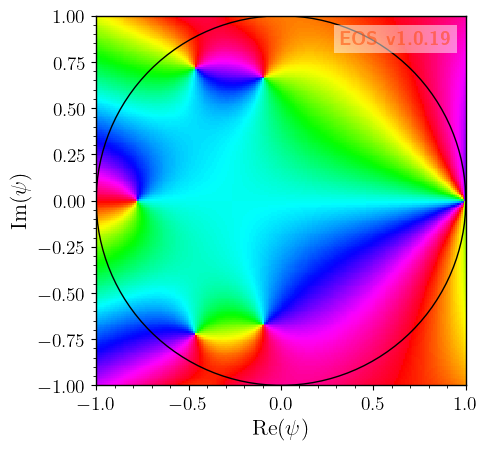

In [ ]:
figure_args = {
'plot': {
    'xaxis': { 'label': r'$\mathrm{Re}(\psi)$', 'range': [-1.0, 1.0] },
    'yaxis': { 'label': r'$\mathrm{Im}(\psi)$', 'range': [-1.0, 1.0] },
    # 'legend': { 'position': 'upper left' },
    'items': [
    { 'type': 'complex-plane', 'label': 'N = 9 fit', 'colormap': 'hsv',
        'variables': ["Re{psi}", "Im{psi}"], 'observable': "0->pipi::Arg{f_+}(Re{psi},Im{psi})@BHKMNR2026",
        'fixed_parameters_from_file': 'data/'+posterior+'/mode-default/parameters.yaml', 'resolution': 200
    }
    ]
}
}
figure = eos.figure.FigureFactory.from_dict(**figure_args)
figure.draw()
circle = plt.Circle((0, 0), 1.0, color='k', fill=False)
figure._ax.add_patch(circle)
figure._ax.set_aspect("equal", adjustable="box")


In [ ]:
eos.tasks.predict_observables(af, posterior, "real-partial-wave-I1", base_directory=BASE_DIRECTORY)
eos.tasks.predict_observables(af, posterior, "imag-partial-wave-I1", base_directory=BASE_DIRECTORY)

Accordion(children=(Output(layout=Layout(height='200px', overflow='auto')),), titles=('data/FF-fp-I1-order9/pr…

Accordion(children=(Output(layout=Layout(height='200px', overflow='auto')),), titles=('data/FF-fp-I1-order9/pr…

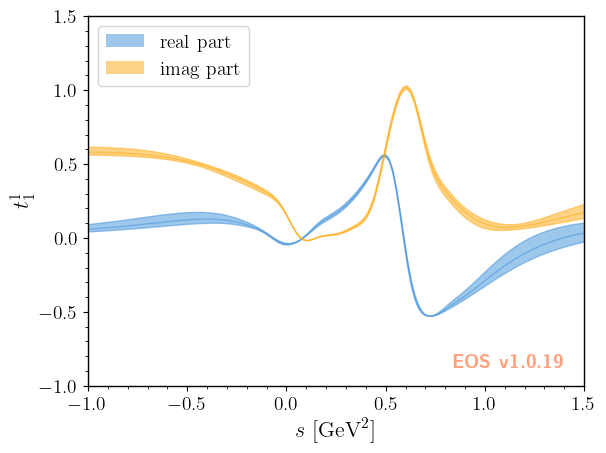

In [ ]:
figure_args = {
  'watermark': { 'position': 'lower right' },
  'plot': {
    'xaxis': { 'label': '$s$', 'unit': '$\\mathrm{GeV}^2$', 'range': [-1.0, 1.5] },
    'yaxis': { 'label': '$t_1^1$',  'range': [-1.0, 1.5]},
    'legend': { 'position': 'upper left' },
    'items': [
      { 'type': 'uncertainty', 'label': 'real part', 'interpolation': 'cubic', 'resolution': 250,
        'variable': 'q2', 'datafile': 'data/'+posterior+'/pred-real-partial-wave-I1'
      },
      { 'type': 'uncertainty', 'label': 'imag part', 'interpolation': 'cubic', 'resolution': 250,
        'variable': 'q2', 'datafile': 'data/'+posterior+'/pred-imag-partial-wave-I1'
      },
    ]
  }
}
figure = eos.figure.FigureFactory.from_dict(**figure_args)
figure.draw()

In [ ]:
# Analytic value of a11
eos.tasks.predict_observables(af, posterior, "FF-fp-I1-scattering-length-params", base_directory=BASE_DIRECTORY)
sl_params = eos.data.Prediction(os.path.join(BASE_DIRECTORY, 'data', posterior, 'pred-FF-fp-I1-scattering-length-params'))

Accordion(children=(Output(layout=Layout(height='200px', overflow='auto')),), titles=('data/FF-fp-I1-order9/pr…

In [ ]:
a11_values = np.array(list(map(a11_calculator, sl_params.samples)))* mpi**2
a11_mean   = np.average(a11_values, weights=sl_params.weights)
a11_std    = wstd(a11_values, weights=sl_params.weights)
print(f"a11 = {a11_mean:.4f} ± {a11_std:.4f}")

a11 = 0.0336 ± 0.0053


In [ ]:
# Charge radius
eos.tasks.predict_observables(af, posterior, "FF-fp-I1-pion-charge-radius-param", base_directory=BASE_DIRECTORY)
fprime_values = eos.data.Prediction(os.path.join(BASE_DIRECTORY, 'data', posterior, 'pred-FF-fp-I1-pion-charge-radius-param'))

Accordion(children=(Output(layout=Layout(height='200px', overflow='auto')),), titles=('data/FF-fp-I1-order9/pr…

In [ ]:
charge_radius_squared_values = np.array(list(map(charge_radius_squared_calculator, fprime_values.samples[:, 0])))
radius_mean  = np.average(charge_radius_squared_values, weights=fprime_values.weights)
radius_std   = wstd(charge_radius_squared_values, weights=fprime_values.weights)

print(f"<r^2> = {radius_mean:.4f} ± {radius_std:.4f} fm^2")

<r^2> = 0.4434 ± 0.0060 fm^2


In [ ]:
# Residue at the rho pole
eos.tasks.predict_observables(af, posterior, "re-rho-residue-psi", base_directory=BASE_DIRECTORY)
re_res_psi = eos.data.Prediction(os.path.join(BASE_DIRECTORY, 'data', posterior, 'pred-re-rho-residue-psi'))
eos.tasks.predict_observables(af, posterior, "im-rho-residue-psi", base_directory=BASE_DIRECTORY)
im_res_psi = eos.data.Prediction(os.path.join(BASE_DIRECTORY, 'data', posterior, 'pred-im-rho-residue-psi'))

Accordion(children=(Output(layout=Layout(height='200px', overflow='auto')),), titles=('data/FF-fp-I1-order9/pr…

Accordion(children=(Output(layout=Layout(height='200px', overflow='auto')),), titles=('data/FF-fp-I1-order9/pr…

In [ ]:
re_res = re_res_psi.samples[:,0]
im_res = im_res_psi.samples[:,0]
M      = f.samples[:,0]
Gamma  = f.samples[:,1]

print(len(re_res), len(im_res), len(M), len(Gamma)) # check that they have the same length

15317 15317 15317 15317


In [ ]:
data = []

for r, i, m, g in zip(re_res, im_res, M, Gamma):
    data.append([r, i, m, g])

with open("residues_psi_order9.wl", "w") as file:
    lines = [f"{{{r}, {i}, {m}, {g}}}" for r, i, m, g in data]
    file.write("{\n" + ",\n".join(lines) + "\n}")

In [ ]:
with open("residues_s_order9.wl") as file:
    text = file.read()

# Replace Mathematica braces with Python brackets
text = text.replace("{", "[").replace("}", "]")

data = ast.literal_eval(text)

In [ ]:
res_s       = np.array([re + 1j * im for re, im in data])
res_s_mean  = np.average(res_s, weights=f.weights)
radius_std  = wstd(res_s, weights=f.weights)
print(f"residue at s_rho is ({np.real(res_s_mean):.4f} ± {np.real(radius_std):.4f}) + i * ({np.imag(res_s_mean):.4f} ± {np.imag(radius_std):.4f})")

residue at s_rho is (-0.7666 ± 0.0135) + i * (0.3188 ± 0.0188)


In [ ]:
# Computing g_{rho pi pi} and g_{rho gamma}
f_at_s_rho       = np.array([get_f_rho(s, analysis) for s in f.samples])
f_at_s_rho_value = f_at_s_rho[:,0] + 1j * f_at_s_rho[:,1]

In [ ]:
s_rho       = (M - 1j * Gamma / 2)**2
g_rho_gamma = np.sqrt(24j * np.pi * s_rho / f_at_s_rho_value / res_s / (np.sqrt(1 - sPlus / s_rho))**3)
g_rho_pi_pi = - res_s / s_rho * g_rho_gamma

In [ ]:
g_rho_gamma_mean = np.average(g_rho_gamma, weights=f.weights)
g_rho_gamma_std  = wstd(g_rho_gamma, weights=f.weights)
print(f"g_rho_gamma =  ({np.real(g_rho_gamma_mean):.4f} ± {np.real(g_rho_gamma_std):.4f}) + i * ({np.imag(g_rho_gamma_mean):.4f} ± {np.imag(g_rho_gamma_std):.4f})")

g_rho_pi_pi_mean = np.average(g_rho_pi_pi, weights=f.weights)
g_rho_pi_pi_std  = wstd(g_rho_pi_pi, weights=f.weights)
print(f"g_rho_pi_pi =  ({np.real(g_rho_pi_pi_mean):.4f} ± {np.real(g_rho_pi_pi_std):.4f}) + i * ({np.imag(g_rho_pi_pi_mean):.4f} ± {np.imag(g_rho_pi_pi_std):.4f})")

g_rho_gamma =  (4.5278 ± 0.0024) + i * (0.2066 ± -0.0096)
g_rho_pi_pi =  (6.3753 ± 0.0710) + i * (-1.0189 ± 0.1670)
